In [2]:
import pandas as pd
import numpy as np

# load the original clean dataset
df = pd.read_csv('train.csv')

# make a copy to intentionally mess up
messy_df = df.copy()

print("Original shape:", messy_df.shape)
messy_df.head()

Original shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
np.random.seed(42)

# 1. Introduce duplicate rows
duplicates = messy_df.sample(20, random_state=42)
messy_df = pd.concat([messy_df, duplicates], ignore_index=True)

# 2. Introduce inconsistent casing in Sex column
random_idx = messy_df.sample(frac=0.15, random_state=1).index
messy_df.loc[random_idx, 'Sex'] = messy_df.loc[random_idx, 'Sex'].str.upper()

# 3. Introduce extra whitespace in Embarked column
random_idx2 = messy_df.sample(frac=0.1, random_state=2).index
messy_df.loc[random_idx2, 'Embarked'] = ' ' + messy_df.loc[random_idx2, 'Embarked'].astype(str) + ' '

# 4. Introduce unrealistic outliers in Age
outlier_idx = messy_df.sample(5, random_state=3).index
messy_df.loc[outlier_idx, 'Age'] = 300

# 5. Introduce negative Fare values (impossible in reality)
negative_idx = messy_df.sample(5, random_state=4).index
messy_df.loc[negative_idx, 'Fare'] = -messy_df.loc[negative_idx, 'Fare']

print("Messy shape:", messy_df.shape)
messy_df.head(10)


Messy shape: (911, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",FEMALE,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",FEMALE,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",MALE,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",FEMALE,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
print("=== DUPLICATE CHECK ===")
print("Number of duplicate rows:", messy_df.duplicated().sum())

print("\n=== SEX COLUMN VALUES ===")
print(messy_df['Sex'].value_counts())

print("\n=== EMBARKED COLUMN VALUES (checking for whitespace) ===")
print(messy_df['Embarked'].unique())

print("\n=== AGE STATISTICS (checking for outliers) ===")
print(messy_df['Age'].describe())

print("\n=== FARE STATISTICS (checking for negative values) ===")
print(messy_df['Fare'].describe())

=== DUPLICATE CHECK ===
Number of duplicate rows: 10

=== SEX COLUMN VALUES ===
Sex
male      499
female    275
MALE       89
FEMALE     48
Name: count, dtype: int64

=== EMBARKED COLUMN VALUES (checking for whitespace) ===
['S' 'C' 'Q' ' S ' nan ' C ' ' Q ']

=== AGE STATISTICS (checking for outliers) ===
count    732.000000
mean      31.393675
std       26.514237
min        0.420000
25%       20.000000
50%       28.000000
75%       38.250000
max      300.000000
Name: Age, dtype: float64

=== FARE STATISTICS (checking for negative values) ===
count    911.000000
mean      31.600132
std       49.526825
min      -78.850000
25%        7.895800
50%       14.454200
75%       30.847900
max      512.329200
Name: Fare, dtype: float64


In [5]:
print("Total rows:", len(messy_df))
print("Unique rows:", len(messy_df.drop_duplicates()))
print("\nAre there duplicate PassengerIds?")
print(messy_df['PassengerId'].duplicated().sum())

Total rows: 911
Unique rows: 901

Are there duplicate PassengerIds?
20


In [6]:
print("Before removing duplicates:", messy_df.shape)

messy_df = messy_df.drop_duplicates(subset='PassengerId', keep='first')

print("After removing duplicates:", messy_df.shape)

Before removing duplicates: (911, 12)
After removing duplicates: (891, 12)


In [7]:
print("Before cleaning:")
print(messy_df['Sex'].value_counts())

messy_df['Sex'] = messy_df['Sex'].str.lower().str.strip()

print("\nAfter cleaning:")
print(messy_df['Sex'].value_counts())

Before cleaning:
Sex
male      490
female    267
MALE       87
FEMALE     47
Name: count, dtype: int64

After cleaning:
Sex
male      577
female    314
Name: count, dtype: int64


In [8]:
print("Before cleaning:")
print(messy_df['Embarked'].unique())

messy_df['Embarked'] = messy_df['Embarked'].str.strip()

print("\nAfter cleaning:")
print(messy_df['Embarked'].unique())

Before cleaning:
['S' 'C' 'Q' ' S ' nan ' C ' ' Q ']

After cleaning:
['S' 'C' 'Q' nan]


In [9]:
print("Passengers with Age > 100:")
print(messy_df[messy_df['Age'] > 100][['PassengerId', 'Name', 'Age']])

Passengers with Age > 100:
     PassengerId                            Name    Age
157          158                 Corn, Mr. Harry  300.0
449          450  Peuchen, Major. Arthur Godfrey  300.0
589          590             Murdlin, Mr. Joseph  300.0
732          733            Knight, Mr. Robert J  300.0
745          746    Crosby, Capt. Edward Gifford  300.0


In [10]:
# treat impossible ages as missing
messy_df.loc[messy_df['Age'] > 100, 'Age'] = np.nan

print("Age > 100 count now:", (messy_df['Age'] > 100).sum())
print("Missing ages now:", messy_df['Age'].isnull().sum())

Age > 100 count now: 0
Missing ages now: 180


In [11]:
print("Passengers with negative Fare:")
print(messy_df[messy_df['Fare'] < 0][['PassengerId', 'Name', 'Fare']])

Passengers with negative Fare:
     PassengerId                          Name     Fare
76            77             Staneff, Mr. Ivan  -7.8958
92            93   Chaffee, Mr. Herbert Fuller -61.1750
239          240        Hunt, Mr. George Henry -12.2750
290          291  Barber, Miss. Ellen "Nellie" -78.8500
817          818            Mallet, Mr. Albert -37.0042


In [12]:
print("Before fixing:")
print(messy_df[messy_df['Fare'] < 0][['PassengerId', 'Fare']])

messy_df['Fare'] = messy_df['Fare'].abs()

print("\nNegative fares remaining:", (messy_df['Fare'] < 0).sum())
print("\nFare statistics after fix:")
print(messy_df['Fare'].describe())

Before fixing:
     PassengerId     Fare
76            77  -7.8958
92            93 -61.1750
239          240 -12.2750
290          291 -78.8500
817          818 -37.0042

Negative fares remaining: 0

Fare statistics after fix:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [13]:
messy_df['Title'] = messy_df['Name'].str.extract(r',\s*([^\.]+)\.')

print(messy_df['Title'].value_counts())



Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [14]:
print("Missing ages before imputation:", messy_df['Age'].isnull().sum())

messy_df['Age'] = messy_df.groupby('Title')['Age'].transform(
    lambda x: x.fillna(x.median())
)

print("Missing ages after imputation:", messy_df['Age'].isnull().sum())
print("\nAge statistics after imputation:")
print(messy_df['Age'].describe())


Missing ages before imputation: 180
Missing ages after imputation: 1

Age statistics after imputation:
count    890.000000
mean      29.336708
std       13.191203
min        0.420000
25%       21.000000
50%       30.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


In [15]:
missing_age_row = messy_df[messy_df['Age'].isnull()]
print(missing_age_row[['PassengerId', 'Name', 'Title', 'Age']])


     PassengerId                          Name Title  Age
745          746  Crosby, Capt. Edward Gifford  Capt  NaN


In [16]:
overall_median_age = messy_df['Age'].median()
print("Overall median age:", overall_median_age)

messy_df['Age'] = messy_df['Age'].fillna(overall_median_age)

print("\nMissing ages remaining:", messy_df['Age'].isnull().sum())

Overall median age: 30.0

Missing ages remaining: 0


In [17]:
print("Missing Embarked:", messy_df['Embarked'].isnull().sum())
print("Missing Cabin:", messy_df['Cabin'].isnull().sum())
print("Cabin missing percentage:", round(messy_df['Cabin'].isnull().sum() / len(messy_df) * 100, 1), "%")

Missing Embarked: 2
Missing Cabin: 687
Cabin missing percentage: 77.1 %


In [18]:
# create a new feature instead of dropping the column
messy_df['HasCabin'] = messy_df['Cabin'].notnull().astype(int)

print(messy_df['HasCabin'].value_counts())

# now we can drop the original Cabin column since we extracted its signal
messy_df = messy_df.drop('Cabin', axis=1)

print("\nColumns remaining:", messy_df.columns.tolist())


HasCabin
0    687
1    204
Name: count, dtype: int64

Columns remaining: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Title', 'HasCabin']


In [19]:
messy_df['Embarked'] = messy_df['Embarked'].fillna(messy_df['Embarked'].mode()[0])

print("Missing Embarked remaining:", messy_df['Embarked'].isnull().sum())

Missing Embarked remaining: 0


In [20]:
print("=== FINAL MISSING VALUE CHECK ===")
print(messy_df.isnull().sum())

print("\n=== FINAL SHAPE ===")
print(messy_df.shape)

=== FINAL MISSING VALUE CHECK ===
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
HasCabin       0
dtype: int64

=== FINAL SHAPE ===
(891, 13)


In [22]:
print("=== NUMERIC COLUMNS SUMMARY ===")
print(messy_df.describe())

print("\n=== CATEGORICAL COLUMNS SUMMARY ===")
print(messy_df.describe(include='object'))

=== NUMERIC COLUMNS SUMMARY ===
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.337452    0.523008   
std     257.353842    0.486592    0.836071   13.183809    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   21.000000    0.000000   
50%     446.000000    0.000000    3.000000   30.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare    HasCabin  
count  891.000000  891.000000  891.000000  
mean     0.381594   32.204208    0.228956  
std      0.806057   49.693429    0.420397  
min      0.000000    0.000000    0.000000  
25%      0.000000    7.910400    0.000000  
50%      0.000000   14.454200    0.000000  
75%      0.000000   31.000000

In [23]:
print("Fare mean:", messy_df['Fare'].mean())
print("Fare median:", messy_df['Fare'].median())
print("Fare skewness:", messy_df['Fare'].skew())

Fare mean: 32.204207968574636
Fare median: 14.4542
Fare skewness: 4.787316519674893


In [24]:
print("Top 10 highest fares:")
print(messy_df[['Name', 'Pclass', 'Fare']].sort_values('Fare', ascending=False).head(10))

Top 10 highest fares:
                                                Name  Pclass      Fare
679               Cardeza, Mr. Thomas Drake Martinez       1  512.3292
258                                 Ward, Miss. Anna       1  512.3292
737                           Lesurer, Mr. Gustave J       1  512.3292
88                        Fortune, Miss. Mabel Helen       1  263.0000
438                                Fortune, Mr. Mark       1  263.0000
341                   Fortune, Miss. Alice Elizabeth       1  263.0000
27                    Fortune, Mr. Charles Alexander       1  263.0000
742            Ryerson, Miss. Susan Parker "Suzette"       1  262.3750
311                       Ryerson, Miss. Emily Borie       1  262.3750
299  Baxter, Mrs. James (Helene DeLaudeniere Chaput)       1  247.5208


In [25]:
correlation_matrix = messy_df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin']].corr()

print(correlation_matrix['Survived'].sort_values(ascending=False))

Survived    1.000000
HasCabin    0.316912
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077369
Pclass     -0.338481
Name: Survived, dtype: float64


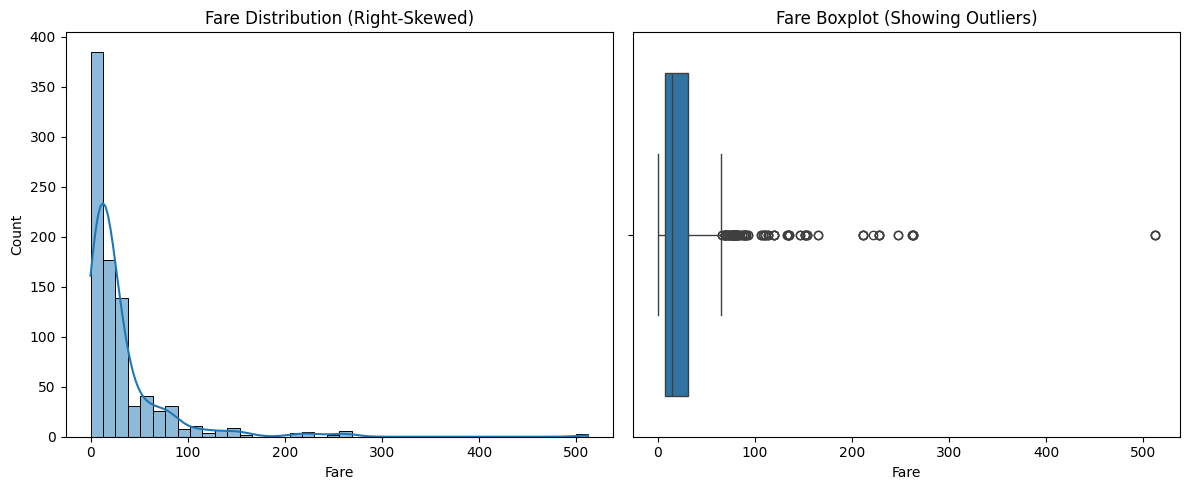

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(messy_df['Fare'], bins=40, kde=True)
plt.title('Fare Distribution (Right-Skewed)')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(x=messy_df['Fare'])
plt.title('Fare Boxplot (Showing Outliers)')
plt.xlabel('Fare')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1665/3423423833.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['No Cabin', 'Has Cabin'])


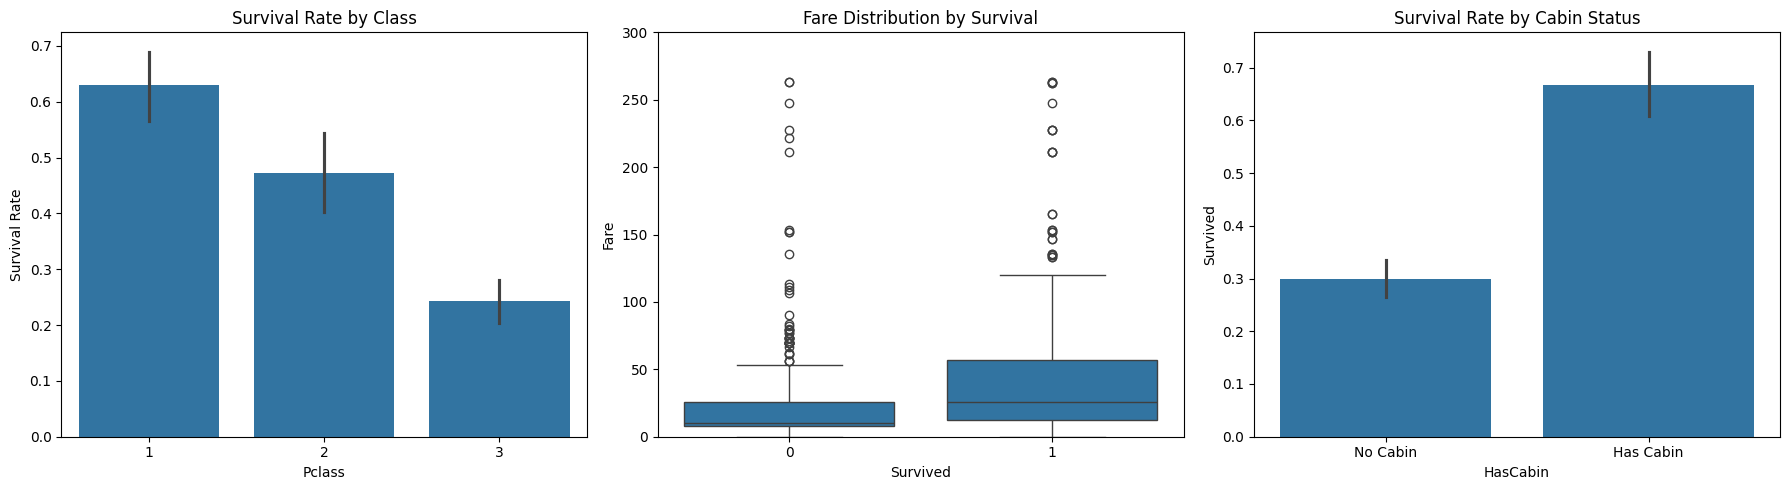

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Pclass', y='Survived', data=messy_df, ax=axes[0])
axes[0].set_title('Survival Rate by Class')
axes[0].set_ylabel('Survival Rate')

sns.boxplot(x='Survived', y='Fare', data=messy_df, ax=axes[1])
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_ylim(0, 300)

sns.barplot(x='HasCabin', y='Survived', data=messy_df, ax=axes[2])
axes[2].set_title('Survival Rate by Cabin Status')
axes[2].set_xticklabels(['No Cabin', 'Has Cabin'])

plt.tight_layout()
plt.show()

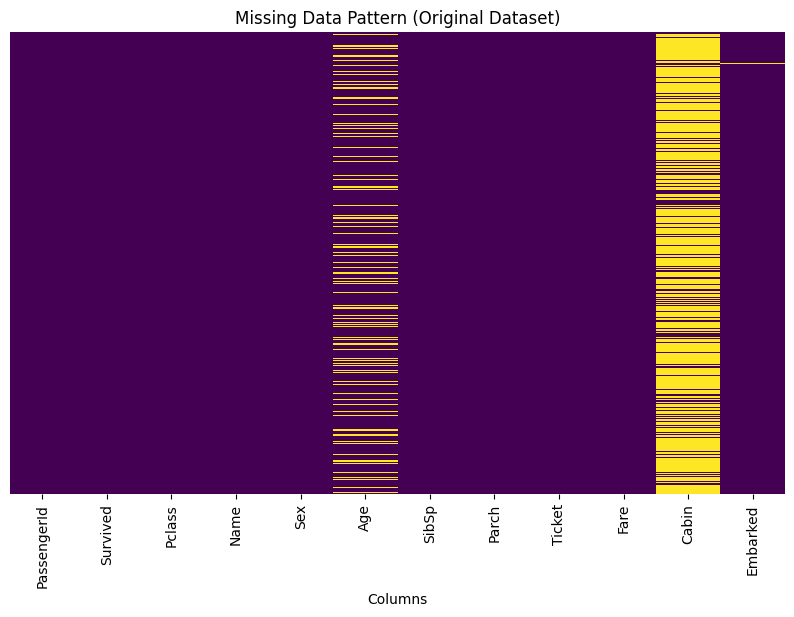

In [28]:
# recreate the original messy version's missing data pattern for visualization
original_missing = df.copy()  # df is your original untouched dataset from Step 1

plt.figure(figsize=(10, 6))
sns.heatmap(original_missing.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Pattern (Original Dataset)')
plt.xlabel('Columns')
plt.show()


In [ ]:
title_survival = df2.groupby('Title')['Survived'].mean() * 100

print(title_survival.round(1))

plt.figure(figsize=(8,5))
sns.barplot(x='Title', y='Survived', data=df2)
plt.title('Survival Rate by Title')
plt.ylabel('Survival rate')
plt.xlabel('Title')
plt.show()

In [ ]:
title_mapping = {
    'Mr': 0,
    'Miss': 1,
    'Mrs': 2,
    'Master': 3,
    'Rare': 4
}

df2['Title'] = df2['Title'].map(title_mapping)

# encode Sex too
df2['Sex'] = df2['Sex'].map({'male': 0, 'female': 1})

# encode Embarked
df2['Embarked'] = df2['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print(df2[['Name', 'Title', 'Sex', 'Embarked']].head())

In [ ]:
# add family features
df2['FamilySize'] = df2['SibSp'] + df2['Parch'] + 1
df2['IsAlone'] = (df2['FamilySize'] == 1).astype(int)

# define features and target
X = df2[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
          'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone']]
y = df2['Survived']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train tuned random forest
model_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model_final.fit(X_train, y_train)
y_pred_final = model_final.predict(X_test)

print("Final model accuracy:", round(accuracy_score(y_test, y_pred_final), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))
print("Final model accuracy:", round(accuracy_score(y_test, y_pred_final), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

In [ ]:
from google.colab import files

df2.to_csv('titanic_clean.csv', index=False)
files.download('titanic_clean.csv')